In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from mpl_toolkits.mplot3d import Axes3D


In [2]:
# Cell 2: Calculate similarities (may take a few seconds)
np.random.seed(42)
vec_1 = np.random.randn(1024)
vec_2 = vec_1.copy()

steps_val = 20      # Number of value steps (log-scale)
steps_zeros = 20    # Number of zero-count points

values = np.logspace(1, 5, steps_val)
num_zeros_list = np.linspace(0, 100, steps_zeros, dtype=int)

X, Y = np.meshgrid(values, num_zeros_list)
Z = np.zeros_like(X, dtype=float)

for i, num_zeros in enumerate(num_zeros_list):
    for j, val in enumerate(values):
        evolving_values_1 = np.ones(100) * val
        evolving_values_1[:num_zeros] = 0
        evolving_values_2 = np.ones(100) * val

        v1 = np.concatenate([vec_1, evolving_values_1])
        v2 = np.concatenate([vec_2, evolving_values_2])

        sim = cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0, 0]
        Z[i, j] = sim

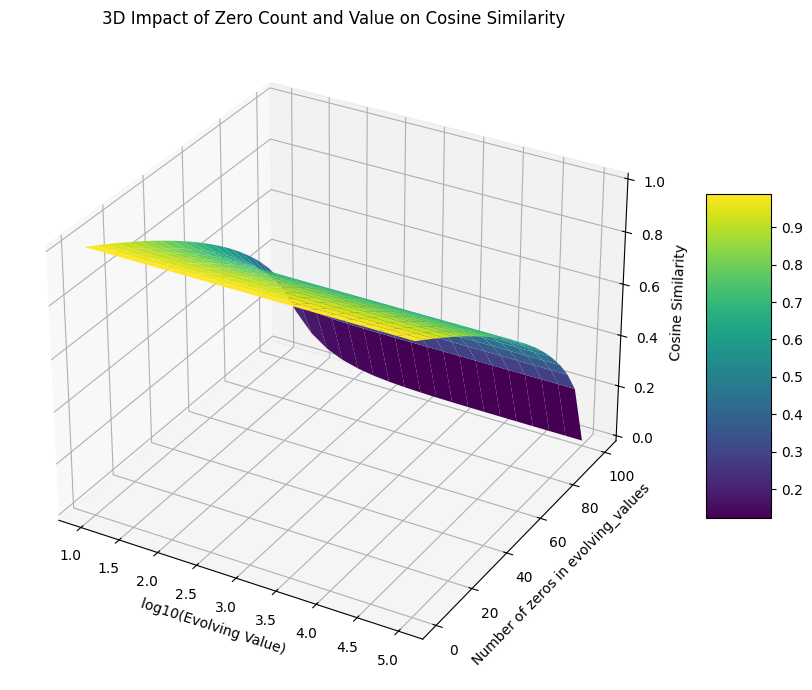

In [3]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(np.log10(X), Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('log10(Evolving Value)')
ax.set_ylabel('Number of zeros in evolving_values')
ax.set_zlabel('Cosine Similarity')
ax.set_title('3D Impact of Zero Count and Value on Cosine Similarity')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

inline


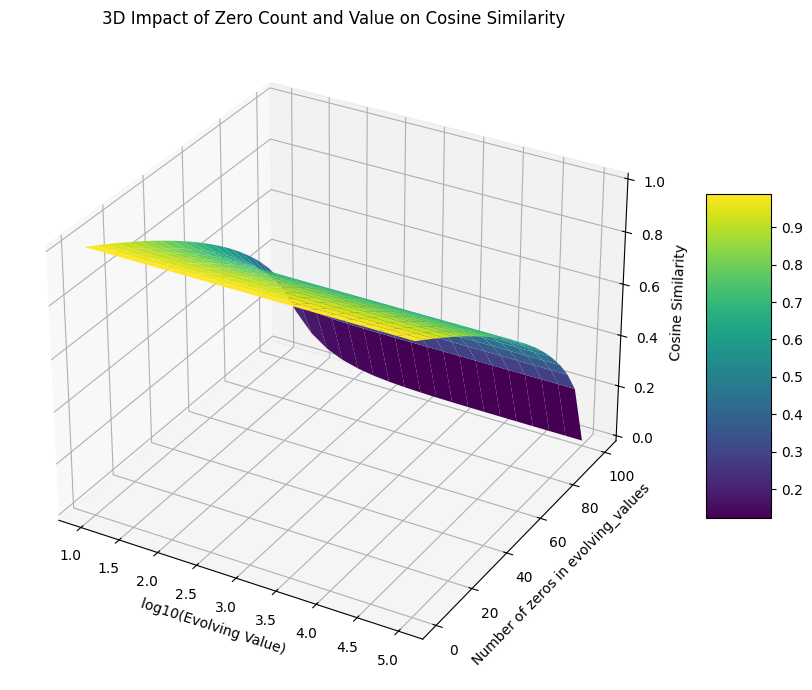

In [4]:
# Cell 1 (always first)
%matplotlib inline

# Cell 2, check backend
import matplotlib
print(matplotlib.get_backend())

# Cell 3 (the code to plot)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from mpl_toolkits.mplot3d import Axes3D

# Generate vectors & similarity grid as before
np.random.seed(42)
vec_1 = np.random.randn(1024)
vec_2 = vec_1.copy()
steps_val = 20
steps_zeros = 20
values = np.logspace(1, 5, steps_val)
num_zeros_list = np.linspace(0, 100, steps_zeros, dtype=int)
X, Y = np.meshgrid(values, num_zeros_list)
Z = np.zeros_like(X, dtype=float)
for i, num_zeros in enumerate(num_zeros_list):
    for j, val in enumerate(values):
        evolving_values_1 = np.ones(100) * val
        evolving_values_1[:num_zeros] = 0
        evolving_values_2 = np.ones(100) * val
        v1 = np.concatenate([vec_1, evolving_values_1])
        v2 = np.concatenate([vec_2, evolving_values_2])
        sim = cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0, 0]
        Z[i, j] = sim

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(np.log10(X), Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('log10(Evolving Value)')
ax.set_ylabel('Number of zeros in evolving_values')
ax.set_zlabel('Cosine Similarity')
ax.set_title('3D Impact of Zero Count and Value on Cosine Similarity')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

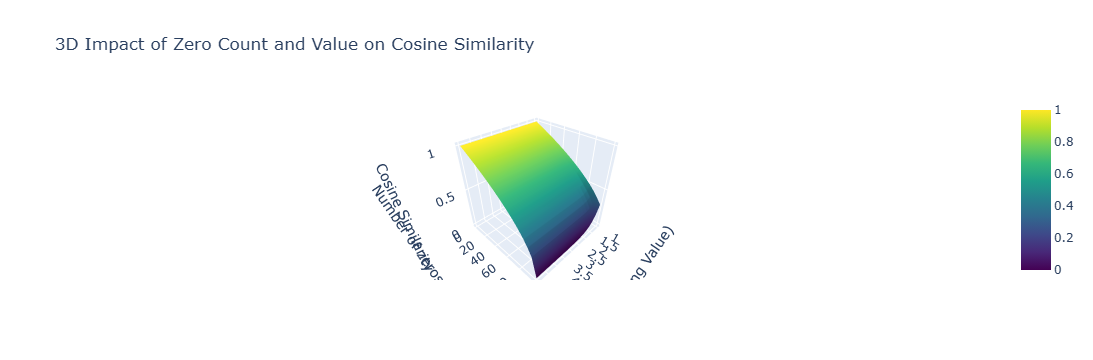

In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import plotly.graph_objs as go

# Generate data
np.random.seed(42)
vec_1 = np.random.randn(1024)
vec_2 = vec_1.copy()

steps_val = 20
steps_zeros = 20
values = np.logspace(1, 5, steps_val)
num_zeros_list = np.linspace(0, 100, steps_zeros, dtype=int)

X, Y = np.meshgrid(values, num_zeros_list)
Z = np.zeros_like(X, dtype=float)

for i, num_zeros in enumerate(num_zeros_list):
    for j, val in enumerate(values):
        evolving_values_1 = np.ones(100) * val
        evolving_values_1[:num_zeros] = 0
        evolving_values_2 = np.ones(100) * val

        v1 = np.concatenate([vec_1, evolving_values_1])
        v2 = np.concatenate([vec_2, evolving_values_2])
        sim = cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0, 0]
        Z[i, j] = sim

# Interactive Plotly 3D surface
fig = go.Figure(
    data=[
        go.Surface(
            z=Z,
            x=np.log10(X),
            y=Y,
            colorscale='Viridis'
        )
    ]
)

fig.update_layout(
    title="3D Impact of Zero Count and Value on Cosine Similarity",
    scene=dict(
        xaxis_title='log10(Evolving Value)',
        yaxis_title='Number of zeros in evolving_values',
        zaxis_title='Cosine Similarity'
    ),
)

# Save the plot as an interactive HTML file
fig.write_html("cosine_similarity_3d.html")

# Optional: show figure directly in notebook (if notebook supports it)
fig.show()